# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns



### Understanding the structure of the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Copying data to another variable to avoid any changes to the original data
df = data.copy()

In [ ]:
# read the data
data = pd.read_csv('/content/drive/MyDrive/week 2/foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here


# Use the shape attribute to find the number of rows and columns
num_rows, num_columns = df.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")


Number of rows: 1898
Number of columns: 9


#### Observations:
Data contains 1898 unique orders based on unique of order


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Use info() to print a concise summary of the DataFrame

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
There are 4 object type columns.
There are 4 integer type columns.
There is 1 floating number type columns.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Write your code here
# Check for missing values in the DataFrame
missing_values = df.isnull().sum()

# Display columns with missing values (if any)
print(missing_values[missing_values > 0])


Series([], dtype: int64)


#### Observations:There are no empty cells in data dictionary, considering in the rating column "Not given" as a type of rating.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


#### Observations:
The minimum time is 20.0 minutes for food to be prepared once an order is placed.
The average time is 27.37 minutes for food to be prepared once an order is placed.
The maximum time is 35.0 minutes for food to be prepared once an order is placed.
```




### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here

not_rated_count = (df['rating'] == 'Not given').sum()
print("Number of orders not rated:", not_rated_count)


total_orders = len(df)

percentage_not_rated = (not_rated_count / total_orders) * 100
print(f"Percentage of orders not rated: {percentage_not_rated:.2f}%")







Number of orders not rated: 736
Percentage of orders not rated: 38.78%


#### Observations:
Out of 1898 orders, 736 orders have not been rated. 38.78% of the orders haven't been rated.

```
# This is formatted as code

```




### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

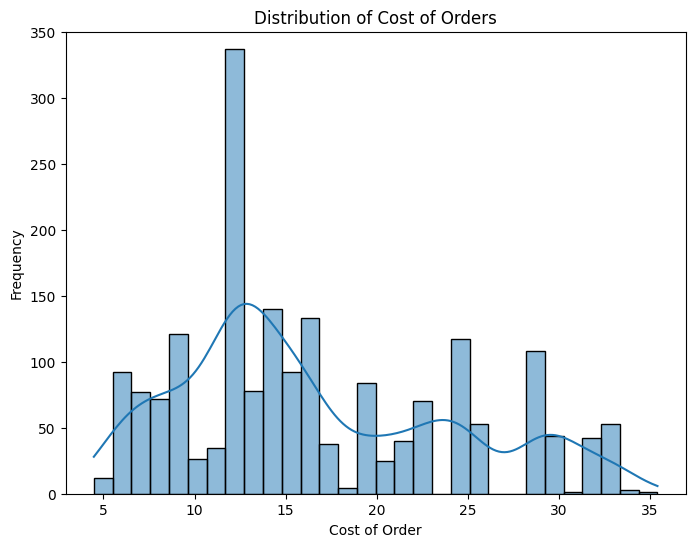

<Figure size 640x480 with 0 Axes>

In [ ]:
# Write the code here
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as clt

# Example: Explore 'cost_of_the_order' variable with a histogram
plt.figure(figsize=(8, 6))
sns.histplot(data['cost_of_the_order'], bins=30, kde=True)
plt.title('Distribution of Cost of Orders')
plt.xlabel('Cost of Order')
plt.ylabel('Frequency')
plt.ylim(0,350)
plt.show()
plt.savefig("output.jpg", bbox_inches='tight')

#### Observations:
The graph is right/ poistively skewed , it shows that dishes with a cost of the order less than 17 are in high demand. There is a decrease in number of order as cost increases.

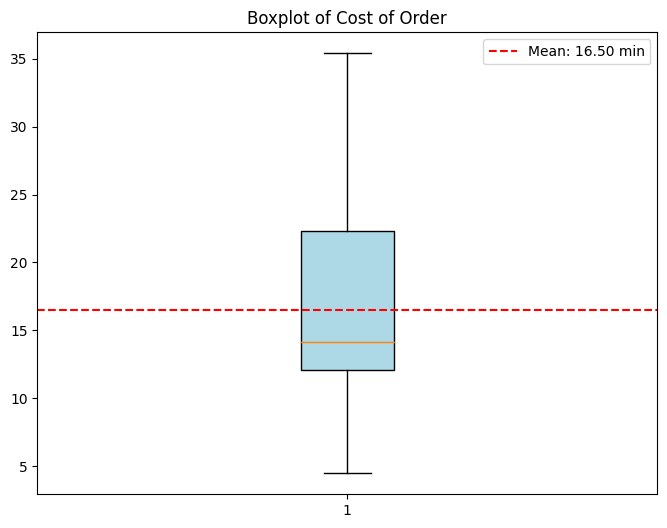

Mean cost of the order: 16.499
25th percentile: 12.08
50th percentile: 14.14
75th percentile: 22.2975


<Figure size 640x480 with 0 Axes>

In [ ]:

# Calculate the mean of the 'delivery_time' column
mean_cost_of_the_order = data['cost_of_the_order'].mean()



# Assuming 'data' contains your DataFrame and 'cost_of_the_order' is a column in it
plt.figure(figsize=(8, 6))
plt.boxplot(data['cost_of_the_order'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.axhline(y=mean_cost_of_the_order, color='red', linestyle='--', label=f'Mean: {mean_cost_of_the_order:.2f} min')
plt.title('Boxplot of Cost of Order')
plt.legend()
plt.show()


# Calculate the mean of the 'cost_of_the_order' column
mean_cost = np.mean(data['cost_of_the_order'])

print(f"Mean cost of the order: {mean_cost:.3f}")

# Calculate the 25th and 75th percentiles
percentile_25 = np.percentile(data['cost_of_the_order'], 25)
percentile_50 = np.percentile(data['cost_of_the_order'], 50)
percentile_75 = np.percentile(data['cost_of_the_order'], 75)

print(f"25th percentile: {percentile_25}")
print(f"50th percentile: {percentile_50}")
print(f"75th percentile: {percentile_75}")

plt.show()
plt.savefig("output.jpg", bbox_inches='tight')


#### Observations:

50% of orders fall within a range of $ 5 - 14 ,the concentration of orders around the median and the decrease in frequency with increasing cost suggest that customers are price-sensitive. The mean is higher than the median, indicating that the tail of the distribution extends towards higher costs.

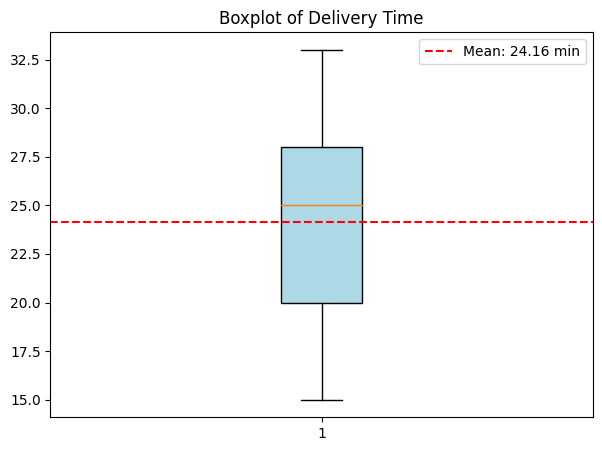

Mean of delivery time: 24.162


<Figure size 640x480 with 0 Axes>

In [ ]:


# Calculate the mean of the 'delivery_time' column
mean_delivery_time = data['delivery_time'].mean()



# Assuming 'data' contains your DataFrame and 'delivery_time' is a column in it
plt.figure(figsize=(7, 5))
plt.boxplot(data['delivery_time'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.axhline(y=mean_delivery_time, color='red', linestyle='--', label=f'Mean: {mean_delivery_time:.2f} min')
plt.title('Boxplot of Delivery Time')
plt.legend()
plt.show()
# Calculate the mean of the 'Delivery time' column
mean_cost = np.mean(data['delivery_time'])

print(f"Mean of delivery time: {mean_cost:.3f}")
plt.savefig("output.jpg", bbox_inches='tight')


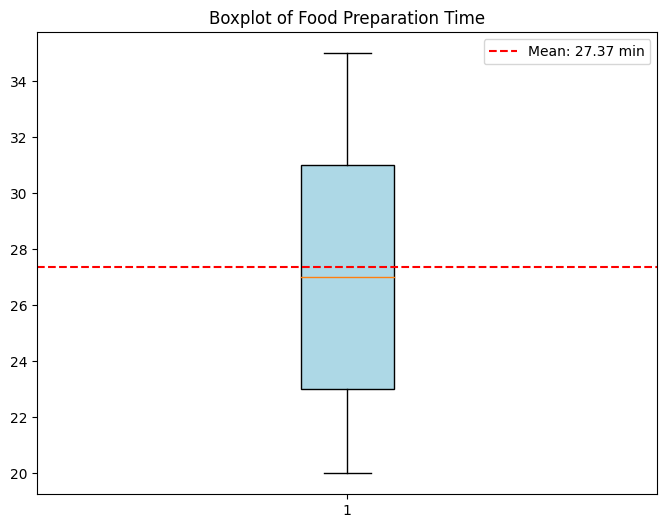

Mean of Food Preparation Time: 27.372


In [ ]:


# Calculate the mean of the 'food_preparation_time' column
mean_food_preparation_time = data['food_preparation_time'].mean()

# Boxplot for 'food_preparation_time'
plt.figure(figsize=(8, 6))
plt.boxplot(data['food_preparation_time'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.axhline(y=mean_food_preparation_time, color='red', linestyle='--', label=f'Mean: {mean_food_preparation_time:.2f} min')
plt.title('Boxplot of Food Preparation Time')
plt.legend()
plt.show()

# Calculate the mean of the 'Food Preparation time' column
mean_cost = np.mean(data['food_preparation_time'])
print(f"Mean of Food Preparation Time: {mean_cost:.3f}")


#### Observations:

The mean and median are almost the same, it indicates that the data is approximately symmetrically distributed.

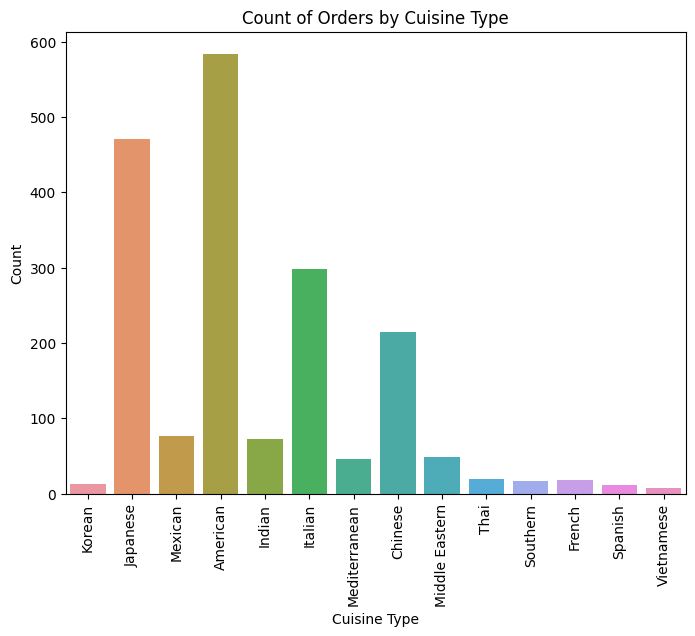

American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: cuisine_type, dtype: int64


In [ ]:

# Explore 'cuisine_type' variable with a countplot
plt.figure(figsize=(8, 6))
sns.countplot(x='cuisine_type', data=data)
plt.title('Count of Orders by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.show()
df = pd.DataFrame(data)

# Count the number of restaurants for each cuisine type
restaurant_count = df['cuisine_type'].value_counts()

print(restaurant_count)

#### Observations:

American cuisine is the most popular, with 584 orders, accounting for 30.8% of the total. Japanese and Italian come in second and third with 470 (24.8%) and 298 (15.7%) orders respectively.

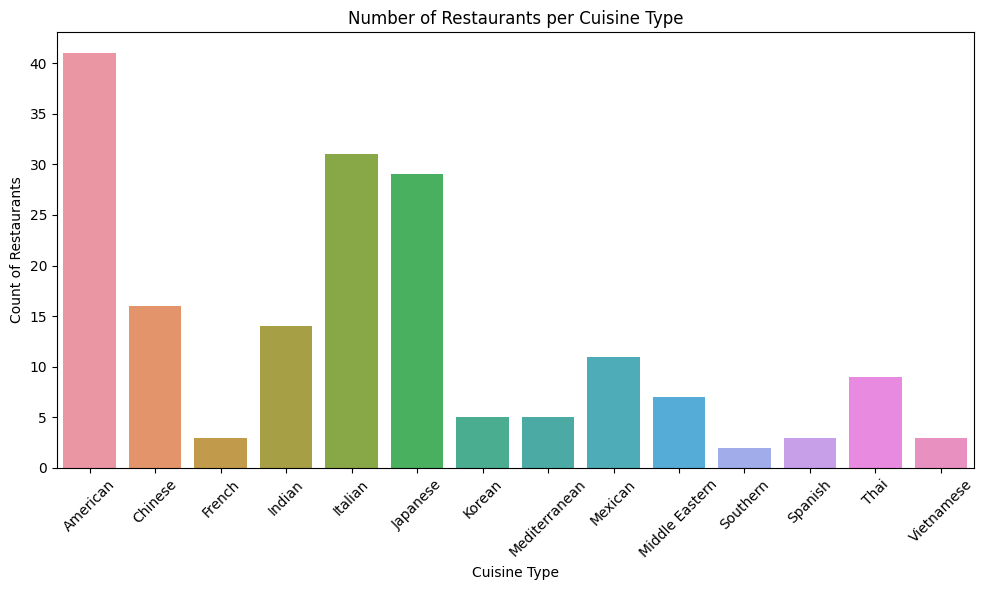

Number of unique restaurants: 178
Number of restaurants per cuisine type:
cuisine_type
American          41
Chinese           16
French             3
Indian            14
Italian           31
Japanese          29
Korean             5
Mediterranean      5
Mexican           11
Middle Eastern     7
Southern           2
Spanish            3
Thai               9
Vietnamese         3
Name: restaurant_name, dtype: int64


In [ ]:


# Assuming 'df' is your DataFrame


# Visualize number of restaurants per cuisine type
plt.figure(figsize=(10, 6))
sns.barplot(x=restaurant_count_per_cuisine.index, y=restaurant_count_per_cuisine.values)
plt.title('Number of Restaurants per Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Count of Restaurants')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

# Count the number of unique restaurants
unique_restaurants = df['restaurant_name'].nunique()
print("Number of unique restaurants:", unique_restaurants)

# Count the number of restaurants for each cuisine type
restaurant_count_per_cuisine = df.groupby('cuisine_type')['restaurant_name'].nunique()
print("Number of restaurants per cuisine type:")
print(restaurant_count_per_cuisine)












#### Observations:
A large number of restaurants have high demand, such as American, Japanese, and Italian. However, Korean, Thai, and Vietnamese restaurants have significantly fewer orders in comparison.


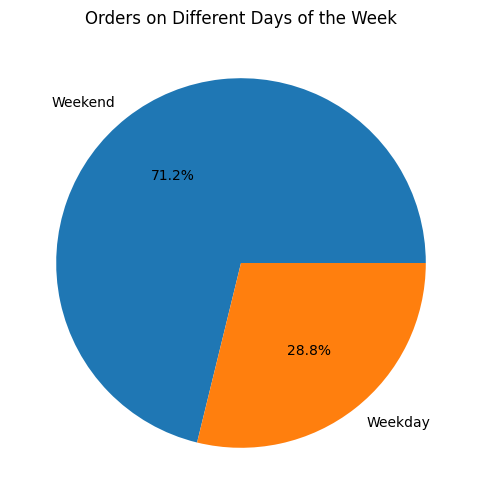

In [ ]:
# Create a pie chart for orders on different days of the week
day_counts = data['day_of_the_week'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(day_counts, labels=day_counts.index, autopct='%1.1f%%')
plt.title('Orders on Different Days of the Week')
plt.show()


#### Observations:
The influx of orders on weekends is considerably higher than on weekdays

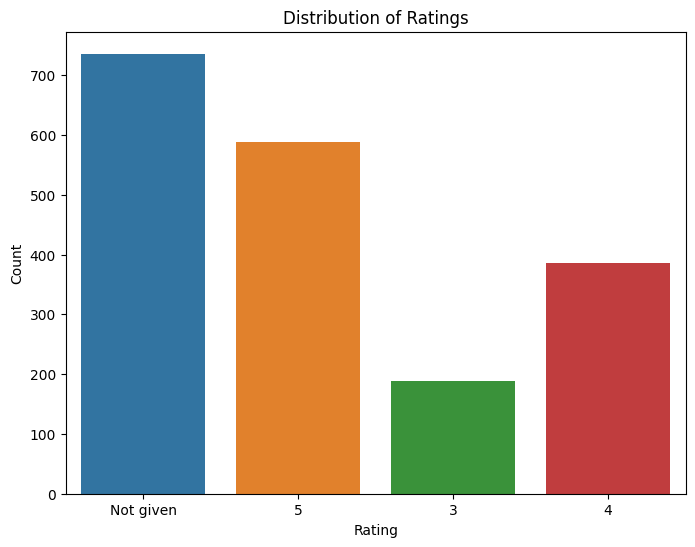

In [ ]:
# Creating a countplot for ratings
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='rating')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

#### Observations:

Many customer avoid giving ratings altogether

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Write the code here
top_restaurants = df['restaurant_name'].value_counts().head(5),
print(top_restaurants)


(Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: restaurant_name, dtype: int64,)


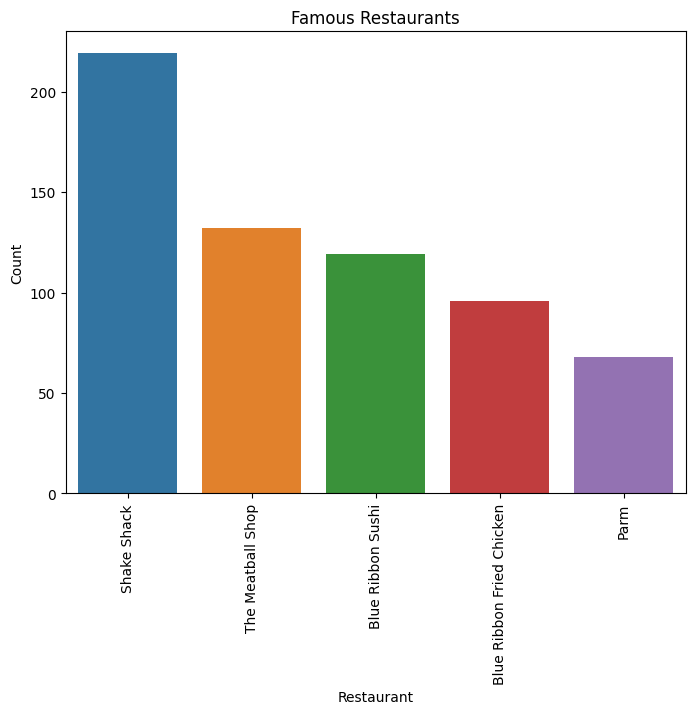

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='restaurant_name', order=data['restaurant_name'].value_counts().head(5).index)
plt.title('Famous Restaurants')
plt.xlabel('Restaurant')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

#### Observations:
Shake Shack is far ahead, followed by The Meatball Shop and Blue Ribbon Sushi.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Write the code here

weekend_cuisine = df[df['day_of_the_week'].isin(['Weekend'])]
popular_cuisine = weekend_cuisine['cuisine_type'].value_counts().idxmax()
print("The most popular cuisine on weekends is:", popular_cuisine)


The most popular cuisine on weekends is: American


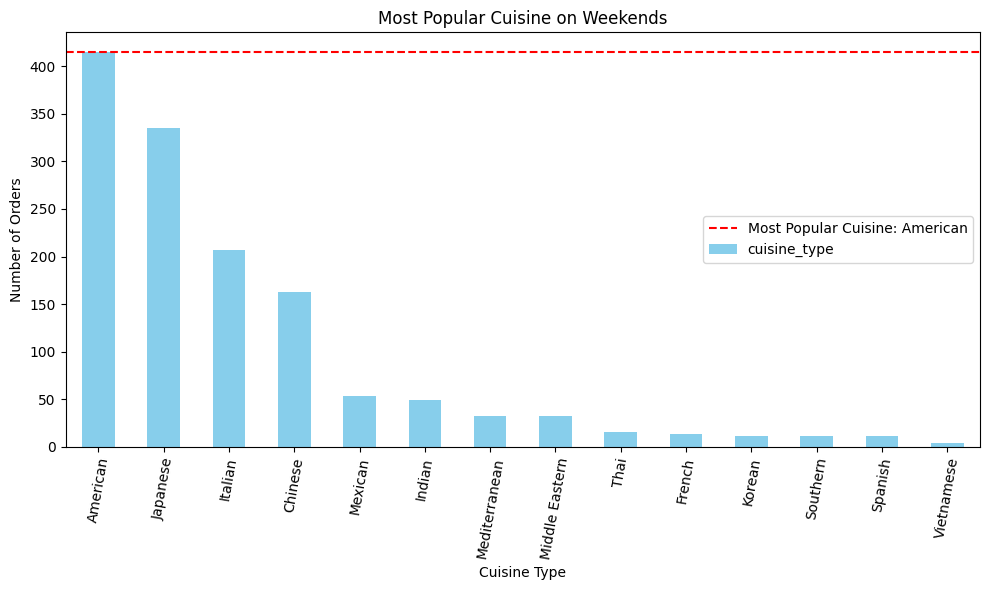

In [ ]:
# Count the occurrences of each cuisine type on weekends
weekend_cuisine = df[df['day_of_the_week'].isin(['Weekend'])]
popular_cuisine = weekend_cuisine['cuisine_type'].value_counts().idxmax()
cuisine_counts = weekend_cuisine['cuisine_type'].value_counts()

# Plotting
plt.figure(figsize=(10, 6))
cuisine_counts.plot(kind='bar', color='skyblue')
plt.title('Most Popular Cuisine on Weekends')
plt.xlabel('Cuisine Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=80)
plt.axhline(y=cuisine_counts.max(), color='red', linestyle='--', label=f'Most Popular Cuisine: {popular_cuisine}')
plt.legend()
plt.tight_layout()
plt.show()

#### Observations:

American cuisine is the most popular, followed by Japanese cuisine


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here

# Count the number of orders with cost > 20
cost_above_20 = df[df['cost_of_the_order'] > 20]
num_orders_above_20 = len(cost_above_20)

# Total number of orders
total_orders = len(df)

# Calculate the percentage
percentage_above_20 = (num_orders_above_20 / total_orders) * 100
print(f"The percentage of orders costing more than 20 dollars is: {percentage_above_20:.2f}%")


The percentage of orders costing more than 20 dollars is: 29.24%


#### Observations:

Most orders are under $20. This finding underscores the importance of catering to budget-conscious customers.

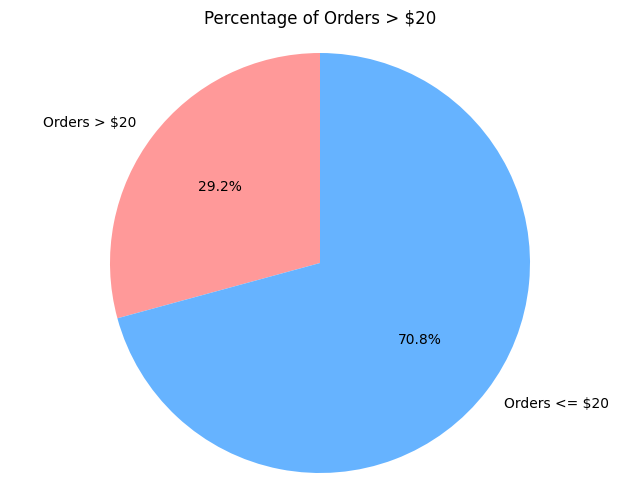

In [ ]:
import matplotlib.pyplot as plt

# Define labels and sizes for the pie chart
cost_above_20 = df[df['cost_of_the_order'] > 20]
num_orders_above_20 = len(cost_above_20)
labels = ['Orders > $20', 'Orders <= $20']
total_orders = len(df)
sizes = [num_orders_above_20, total_orders - num_orders_above_20]
colors = ['#ff9999', '#66b3ff']  # Define colors here

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Orders > $20')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()



#### Observations:

The majority of the orders fall below the $20 mark


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here

mean_delivery_time = df['delivery_time'].mean()
print(f"The mean order delivery time is: {mean_delivery_time:.2f} minutes")


The mean order delivery time is: 24.16 minutes


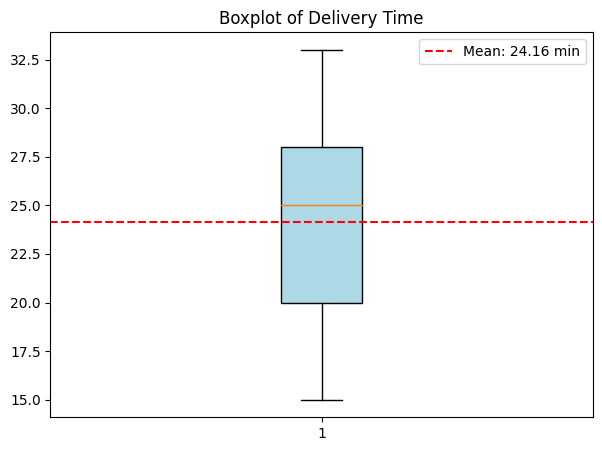

Mean of delivery time: 24.162


In [ ]:

# Calculate the mean of the 'delivery_time' column
mean_delivery_time = data['delivery_time'].mean()



# Assuming 'data' contains your DataFrame and 'delivery_time' is a column in it
plt.figure(figsize=(7, 5))
plt.boxplot(data['delivery_time'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.axhline(y=mean_delivery_time, color='red', linestyle='--', label=f'Mean: {mean_delivery_time:.2f} min')
plt.title('Boxplot of Delivery Time')
plt.legend()
plt.show()
# Calculate the mean of the 'Delivery time' column
mean_cost = np.mean(data['delivery_time'])

print(f"Mean of delivery time: {mean_cost:.3f}")


#### Observations:

Majority of orders are delivered within a tight window of 20-27 minutes, ensuring consistent and efficient delivery.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
customer_order_counts = df['customer_id'].value_counts()
top_customers = customer_order_counts.head(3)

print("Top 3 customers and their order counts:")
print(top_customers)


Top 3 customers and their order counts:
52832    13
47440    10
83287     9
Name: customer_id, dtype: int64


#### Observations:

Offering a 20% discount to these customers is a good way to reward their loyalty and encourage further purchases. It could also nudge them to try new dishes or increase their order size


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


<ipython-input-21-6b6fa4dd7e2d>:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data=df, x="cuisine_type" ,y = "delivery_time", hue="day_of_the_week", style="day_of_the_week", ci = False, markers = True) ;


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Korean'),
  Text(1, 0, 'Japanese'),
  Text(2, 0, 'Mexican'),
  Text(3, 0, 'American'),
  Text(4, 0, 'Indian'),
  Text(5, 0, 'Italian'),
  Text(6, 0, 'Mediterranean'),
  Text(7, 0, 'Chinese'),
  Text(8, 0, 'Middle Eastern'),
  Text(9, 0, 'Thai'),
  Text(10, 0, 'Southern'),
  Text(11, 0, 'French'),
  Text(12, 0, 'Spanish'),
  Text(13, 0, 'Vietnamese')])

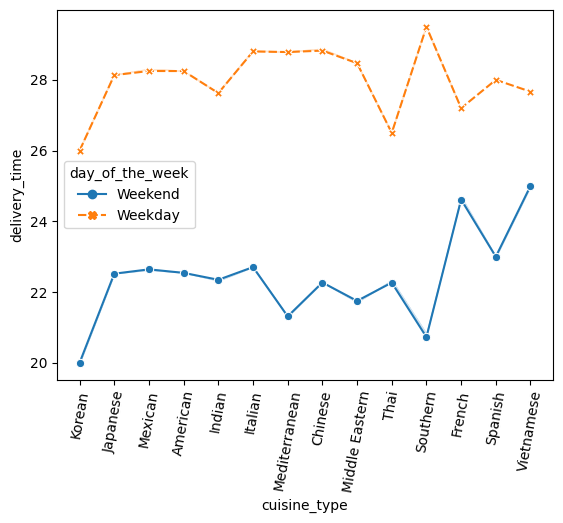

In [ ]:

sns.lineplot(data=df, x="cuisine_type" ,y = "delivery_time", hue="day_of_the_week", style="day_of_the_week", ci = False, markers = True) ;
plt.xticks(rotation=80)

#### Observations:

Delivery times are generally faster on weekdays than on weekends. They also vary significantly between different cuisine types, even during weekends and weekdays. However, some cuisines are consistent in this regard, like Korean, Japanese, Mexican, American, and Italian.

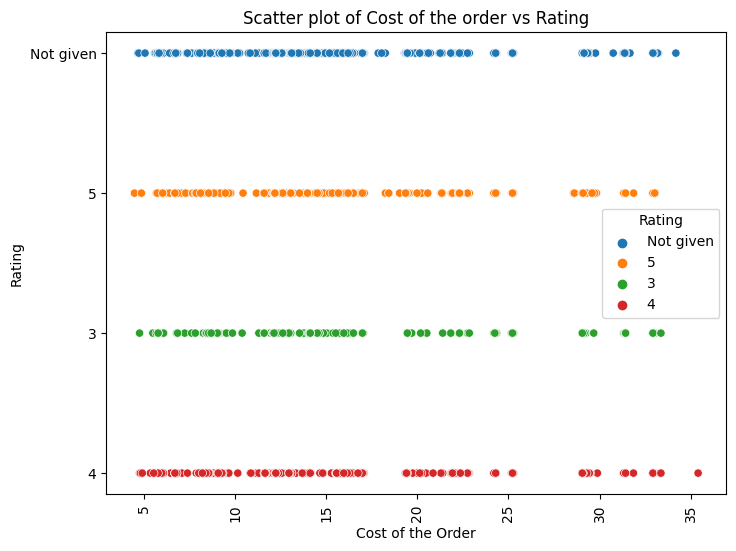

In [ ]:
# Filter the DataFrame for specific ratings
specific_ratings = ['1', '2', '3', '4', '5', 'Not given']
filtered_df = df[df['rating'].isin(specific_ratings)]

# Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=filtered_df, x='cost_of_the_order', y='rating', hue='rating')
plt.title('Scatter plot of Cost of the order vs Rating')
plt.xlabel('Cost of the Order')
plt.ylabel('Rating')
plt.legend(title='Rating')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility
plt.show()

#### Observations:
Overall, not given ratings are consistent,There seems to be a weak positive correlation between cost of the order and rating.

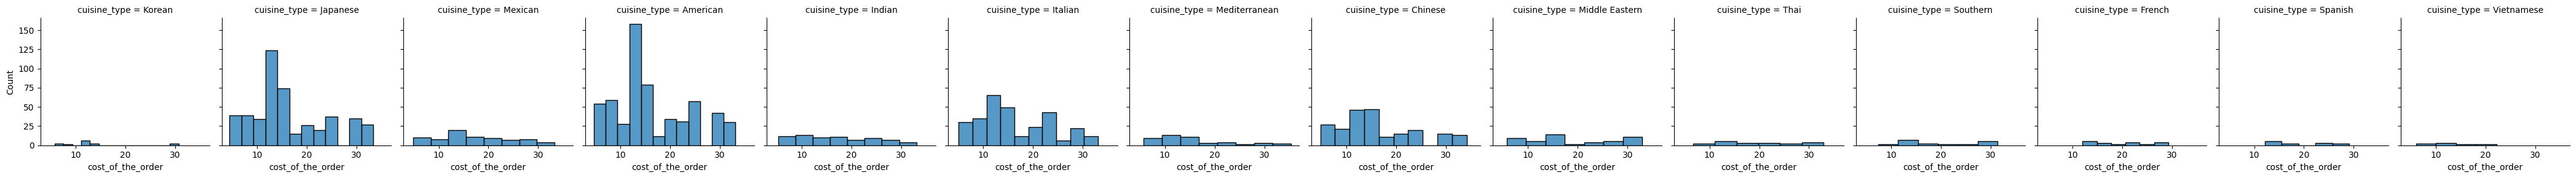

In [ ]:
g = sns.FacetGrid(df, col="cuisine_type")
g.map(sns.histplot, "cost_of_the_order");

#### Observations:
Cost of the order and count of orders are directly propotionate, regardless of the cusine type.

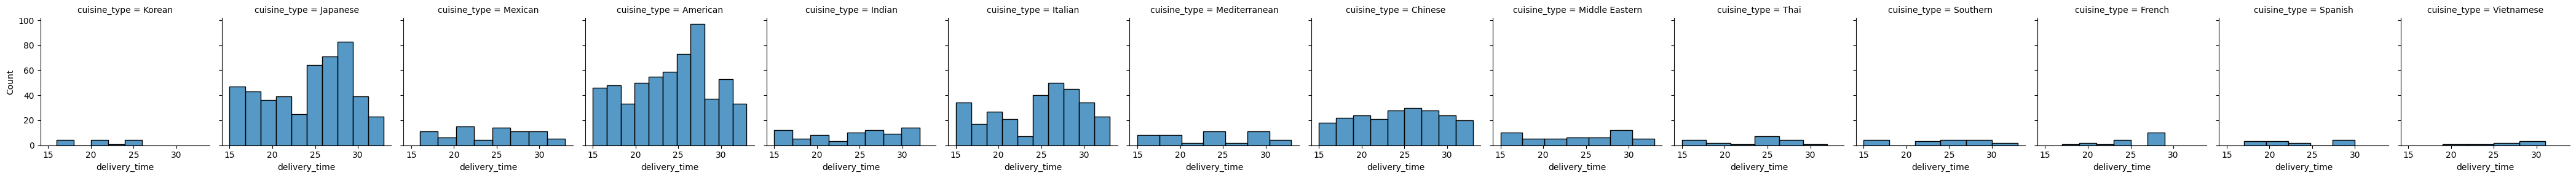

In [ ]:
g = sns.FacetGrid(df, col="cuisine_type")
g.map(sns.histplot, "delivery_time");

#### Observations:
Delivery time of popular cuisine (American, Italian and Japanese) doesn't change  with volume of the orders.

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'Korean'),
  Text(1, 0, 'Japanese'),
  Text(2, 0, 'Mexican'),
  Text(3, 0, 'American'),
  Text(4, 0, 'Indian'),
  Text(5, 0, 'Italian'),
  Text(6, 0, 'Mediterranean'),
  Text(7, 0, 'Chinese'),
  Text(8, 0, 'Middle Eastern'),
  Text(9, 0, 'Thai'),
  Text(10, 0, 'Southern'),
  Text(11, 0, 'French'),
  Text(12, 0, 'Spanish'),
  Text(13, 0, 'Vietnamese')])

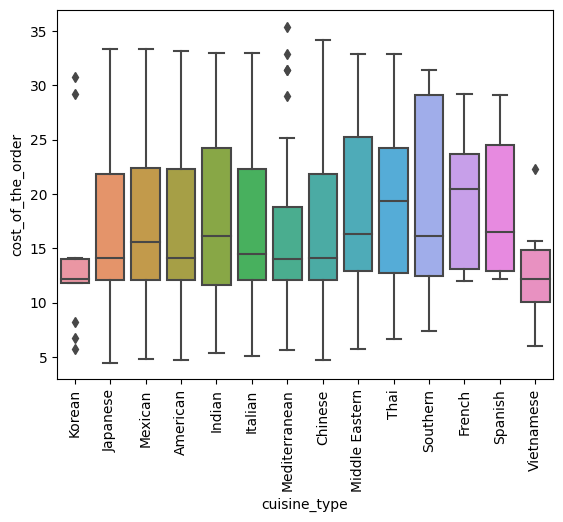

In [ ]:
sns.boxplot(data=df, x='cuisine_type', y='cost_of_the_order')
plt.xticks(rotation=90)


#### Observations:
Most of the cusine have median less than 15 dollars, with the exception of Thai and french cuisine.


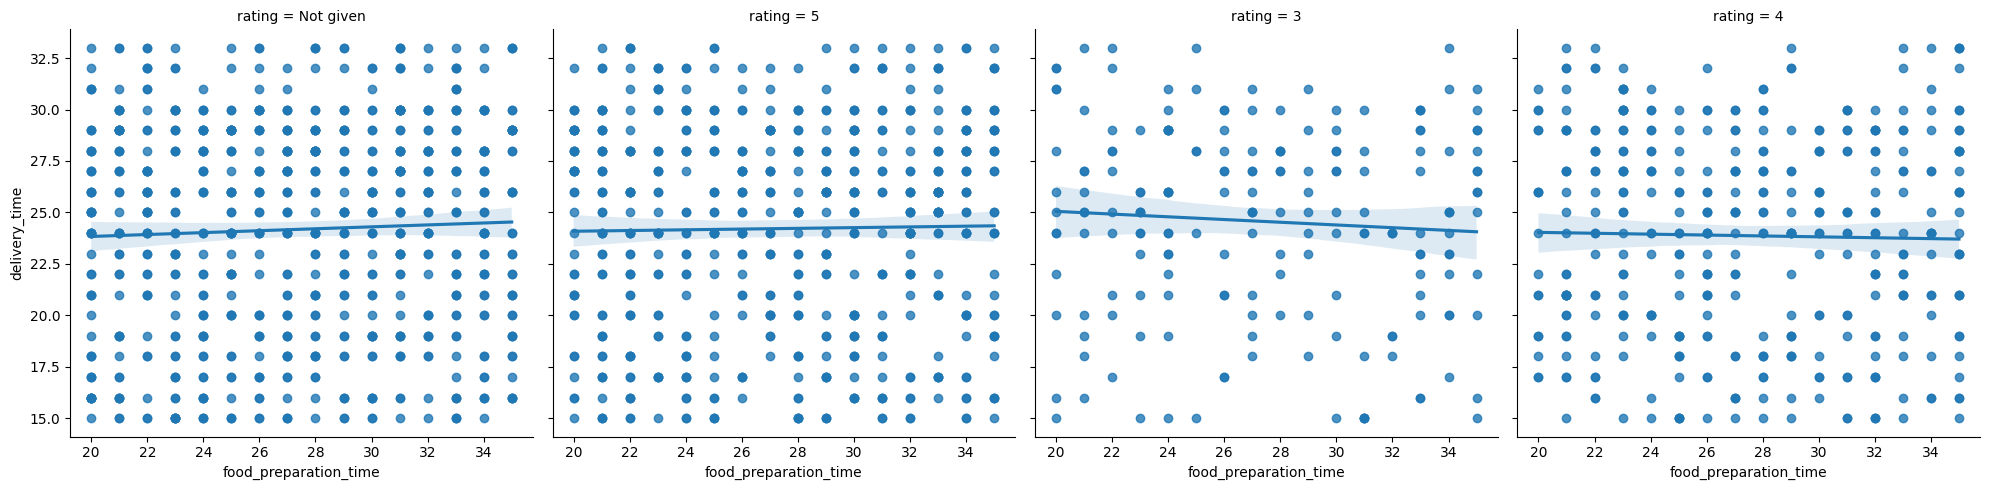

In [80]:
sns.lmplot(data=df, x='food_preparation_time', y='delivery_time', col='rating');


#### Observations:
Customer are pretty consistant in not given rating, regardless of the delivery being quick or delayed.

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'Korean'),
  Text(1, 0, 'Japanese'),
  Text(2, 0, 'Mexican'),
  Text(3, 0, 'American'),
  Text(4, 0, 'Indian'),
  Text(5, 0, 'Italian'),
  Text(6, 0, 'Mediterranean'),
  Text(7, 0, 'Chinese'),
  Text(8, 0, 'Middle Eastern'),
  Text(9, 0, 'Thai'),
  Text(10, 0, 'Southern'),
  Text(11, 0, 'French'),
  Text(12, 0, 'Spanish'),
  Text(13, 0, 'Vietnamese')])

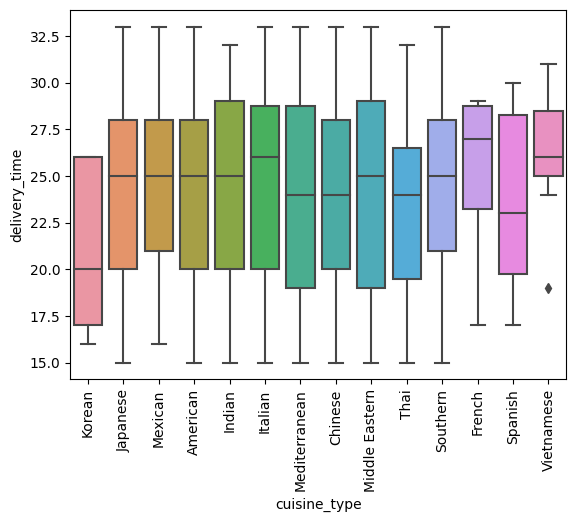

In [78]:
sns.boxplot(data=df, x='cuisine_type', y='delivery_time') ;
plt.xticks(rotation=90)

#### Observations:
50% of Korean cuisine have enjoyed the quickest deliveries at the 20 minutes mark. Whereas most of the cusine are being delivered between 24 - 27 minutes

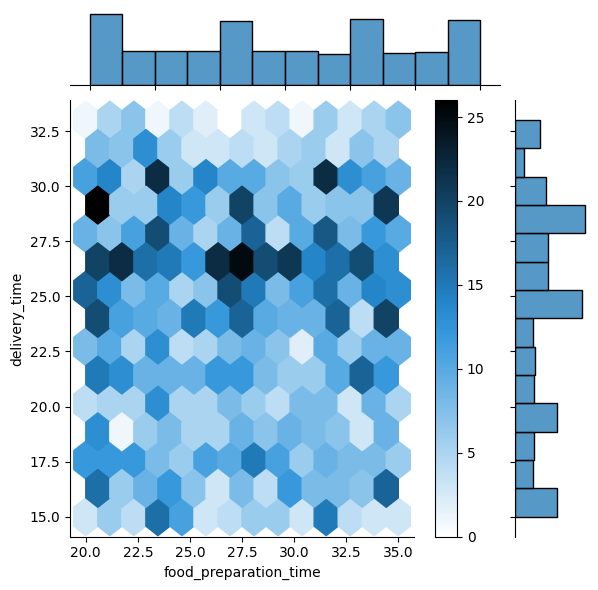

In [ ]:

sns.jointplot(data=df, x='food_preparation_time', y='delivery_time', kind="hex");
plt.colorbar();


#### Observations:

Approximately 89.5% of the order are delivered with in 60 minutes of placing an order by the customers.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Write the code here
df = pd.DataFrame(data)

# Replace 'Not given' ratings with NaN
df['rating'] = df['rating'].replace('Not given', np.nan)

# Convert 'rating' column to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Calculate the rating count for each restaurant
restaurant_rating_count = df.groupby('restaurant_name')['rating'].count()

# Calculate the average rating for each restaurant
restaurant_avg_rating = df.groupby('restaurant_name')['rating'].mean()

# Filter restaurants based on conditions (including those with NaN ratings)
eligible_restaurants = (restaurant_rating_count > 50) & (restaurant_avg_rating > 4)

# Get the names of restaurants meeting the criteria
eligible_restaurant_names = eligible_restaurants[eligible_restaurants].index.tolist()

print("Restaurants eligible for the promotional offer:")
print(eligible_restaurant_names)




Restaurants eligible for the promotional offer:
['Blue Ribbon Fried Chicken', 'Blue Ribbon Sushi', 'Shake Shack', 'The Meatball Shop']


#### Observations:
American, Japanese and Italian restaurants are eligible for the discounts as they are bringing more orders as well able to garner high rating.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Write the code here

# Calculate revenue for orders based on specified criteria
revenue = 0

# Calculate revenue for orders costing more than $20 (25% charge)
revenue += data.loc[data['cost_of_the_order'] > 20, 'cost_of_the_order'].sum() * 0.25

# Calculate revenue for orders costing between $5 and $20 (15% charge)
revenue += data.loc[
    (data['cost_of_the_order'] > 5) & (data['cost_of_the_order'] <= 20), 'cost_of_the_order'
].sum() * 0.15

print(f"Net revenue generated by the company: ${revenue:.2f}")

revenue_25_percent = data.loc[data['cost_of_the_order'] > 20, 'cost_of_the_order'].sum() * 0.25
revenue_15_percent = data.loc[
    (data['cost_of_the_order'] > 5) & (data['cost_of_the_order'] <= 20), 'cost_of_the_order'
].sum() * 0.15

print(f"Net revenue generated by 25% charge orders: ${revenue_25_percent:.2f}")
print(f"Net revenue generated by 15% charge orders: ${revenue_15_percent:.2f}")




Net revenue generated by the company: $6166.30
Net revenue generated by 25% charge orders: $3688.73
Net revenue generated by 15% charge orders: $2477.58


#### Observations:
Company is earning 2477 dollars when the order is less than 20 dollars. On the other hand 3688 dollars is earning when the order are above 20 dollars.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here


# Create a dataset
data["total_time"] = data["food_preparation_time"] + data["delivery_time"]

# Calculate the percentage of orders taking more than 60 minutes for delivery
total_orders = len(data)
more_than_60_minutes = len(data[data["total_time"] > 60])

percentage = (more_than_60_minutes / total_orders) * 100
print(f"Percentage of orders taking more than 60 minutes for delivery: {percentage:.2f}%")


Percentage of orders taking more than 60 minutes for delivery: 10.54%


#### Observations:
 After the placement of an order, 10.54% of the orders are taking more than 60 minutes to be delivered.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Write the code here

# Assuming 'day_of_the_week' contains weekdays and weekends
weekday_mean_delivery_time = df[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean()
weekend_mean_delivery_time = df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean()

print("Mean delivery time on weekdays:", weekday_mean_delivery_time)
print("Mean delivery time on weekends:", weekend_mean_delivery_time)


Mean delivery time on weekdays: 28.340036563071298
Mean delivery time on weekends: 22.4700222057735


#### Observations:
There is a 5 to 6 minutes difference between mean delivery time on weekends vs weekdays.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

* Based on the cuisine type, American, Italian and Japanese are in most demand, they account for 71% of the total orders.
* 38.8% of the orders are not rated.
* Highest rated and most ordered restaurants are from American, Italian and Japanese cuisine
* There is only one rating for both restaurant and delivery service.
* During weekends delivery time extends upto additional 5 minutes
* 50% of the order are $14 and below, it means most of the customer are price sensitive
* Most number of the orders from the popular cuisine are taking between 23- 28 minutes



### Recommendations:

*  In order to reduce the delivery for the popular cuisine, place more riders around these restaurants.
* Ask delivery agent to request customer to provide rating.
* Add two rating type in the app instead of one. One for food quality and for timely delivery experience. This will help us to distinguish rating based on our services.
* Add discount slabs for repeat customers. The higher the number of order, the better discount offers. for examples 10 orders 10% discount, 15 order 15% discount. have expiry or deadlines to create urgency.



---